# Chapter 12 Bayesian Bart: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-12-bayesian-bart-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

In [1]:
"""
Interactive figures for "Bayesian Additive Regression Trees (BART)" (Part 3).

Every function builds one self-contained, standalone Plotly HTML page and writes it to
../_generated/. The matching chapter-bayes-bart.md file embeds each page in an <iframe>, so
the chapter never depends on a live Python kernel to render.

Run directly to regenerate every figure:
    python chapter-bayes-bart-plots.py

The running example extends Chapter 7's simulated canary-rollback classifier (four features:
payload size, canary error rate, hour of day, service dependency count). The BART posterior
draws shown here are a lightweight numpy approximation of what an MCMC chain over a sum-of-trees
model produces, built for a fast, dependency-light demo figure; the chapter prose shows the
`pymc-bart` API a reader would use to fit the model directly. All data is simulated and labeled
as such.
"""

import os

import numpy as np
import plotly.graph_objects as go

RNG = np.random.default_rng(7)
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(＿_file_＿)), "..", "_generated")
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
def save(fig: go.Figure, name: str) -> str:
    path = os.path.join(OUT_DIR, f"{name}.html")
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return path


In [3]:


def simulate_deployments(n: int = 600):
    canary_error_rate = RNG.gamma(shape=1.5, scale=1.2, size=n)
    payload_kb = RNG.lognormal(mean=np.log(15), sigma=0.5, size=n)
    hour_of_day = RNG.integers(0, 24, size=n)
    dependency_count = RNG.poisson(lam=4, size=n)

    logit = (
        -3.2
        + 0.9 * canary_error_rate
        + 0.15 * dependency_count
        + 0.02 * payload_kb
        + 0.15 * np.where((hour_of_day >= 0) & (hour_of_day <= 5), 1, 0) * 3
    )
    prob_rollback = 1 / (1 + np.exp(-logit))
    rollback = RNG.random(n) < prob_rollback
    return canary_error_rate, payload_kb, hour_of_day, dependency_count, rollback


In [4]:


def target_function(x: np.ndarray) -> np.ndarray:
    """A step-like rollback-risk curve as a function of canary error rate, the kind of
    function a sum of shallow trees is well suited to approximate."""
    return 0.15 + 0.55 / (1 + np.exp(-(x - 3.0) * 2.2))


In [5]:


# ---------------------------------------------------------------------------
# Figure 1: many weak trees summing to the ensemble fit as tree count grows
# ---------------------------------------------------------------------------
def fig_ensemble_buildup() -> go.Figure:
    x = np.linspace(0, 6, 200)
    y_true = target_function(x)

    tree_counts = [1, 5, 20, 50, 200]
    frames = []
    for m in tree_counts:
        # Each of m trees contributes a small step function; more trees means finer,
        # more accurate steps, matching BART's "many weak learners" behavior.
        n_steps = max(2, m // 4)
        edges = np.linspace(0, 6, n_steps + 1)
        approx = np.zeros_like(x)
        for lo, hi in zip(edges[:-1], edges[1:]):
            mask = (x >= lo) & (x < hi)
            if mask.any():
                approx[mask] = y_true[mask].mean()
        noise_scale = 0.06 / np.sqrt(m)
        approx_noisy = approx + RNG.normal(0, noise_scale, size=approx.shape)
        frames.append(
            go.Frame(
                name=str(m),
                data=[
                    go.Scatter(x=x, y=y_true, mode="lines", name="true risk curve",
                               line=dict(color="#999", dash="dot", width=2)),
                    go.Scatter(x=x, y=approx_noisy, mode="lines",
                               name=f"sum of {m} weak trees",
                               line=dict(color="#4C78A8", width=3)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="A sum of weak trees approximates the rollback-risk curve as tree count grows",
        xaxis_title="Canary error rate (%)",
        yaxis_title="Predicted rollback probability",
        yaxis_range=[0, 1],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Number of trees in the sum: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [6]:


# ---------------------------------------------------------------------------
# Figure 2: BART posterior predictive interval vs. random forest point estimate
# ---------------------------------------------------------------------------
def fig_bart_vs_rf_interval() -> go.Figure:
    n_deploy = 8
    canary_error_rate, payload_kb, hour_of_day, dependency_count, _ = simulate_deployments(n=600)
    idx = RNG.choice(600, size=n_deploy, replace=False)
    x = canary_error_rate[idx]
    rf_point = target_function(x)

    # Approximate posterior draws for each held-out deployment: more MCMC samples,
    # narrower interval where training data was denser (near the middle of the range).
    n_draws = 400
    density_weight = np.exp(-0.5 * ((x - 3.0) / 2.0) ** 2)
    spread = 0.18 * (1.4 - density_weight)
    draws = rf_point[:, None] + RNG.normal(0, spread[:, None], size=(n_deploy, n_draws))
    draws = np.clip(draws, 0, 1)
    lower = np.percentile(draws, 3, axis=1)
    upper = np.percentile(draws, 97, axis=1)
    bart_mean = draws.mean(axis=1)

    order = np.argsort(x)
    labels = [f"deployment {i+1}" for i in range(n_deploy)]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=[labels[i] for i in order], y=[rf_point[i] for i in order],
        mode="markers", name="random forest point estimate",
        marker=dict(color="#F58518", size=12, symbol="diamond"),
    ))
    fig.add_trace(go.Scatter(
        x=[labels[i] for i in order], y=[bart_mean[i] for i in order],
        mode="markers", name="BART posterior mean",
        marker=dict(color="#4C78A8", size=10),
        error_y=dict(
            type="data",
            symmetric=False,
            array=[upper[i] - bart_mean[i] for i in order],
            arrayminus=[bart_mean[i] - lower[i] for i in order],
            color="#4C78A8", thickness=2, width=6,
        ),
    ))
    fig.update_layout(
        title="Random forest point estimate vs. BART posterior mean with a 94% credible interval",
        yaxis_title="Predicted rollback probability",
        yaxis_range=[0, 1],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [7]:


# ---------------------------------------------------------------------------
# Figure 3: posterior split-inclusion variable importance
# ---------------------------------------------------------------------------
def fig_variable_importance_posterior() -> go.Figure:
    variables = ["canary error rate", "service dependency\ncount", "payload size",
                 "hour of day"]
    # Posterior split-inclusion proportions, simulated with plausible spread across draws.
    means = np.array([0.52, 0.24, 0.15, 0.09])
    n_draws = 300
    draws = RNG.dirichlet(means * 40, size=n_draws)

    fig = go.Figure()
    for i, var in enumerate(variables):
        fig.add_trace(go.Box(
            y=draws[:, i], name=var, marker_color="#4C78A8", boxmean=True,
        ))
    fig.update_layout(
        title="Posterior split-inclusion proportion by predictor, across MCMC draws",
        yaxis_title="Share of splits using this predictor",
        showlegend=False,
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [8]:


# ---------------------------------------------------------------------------
# Figure 4: MCMC trace-style convergence diagnostic
# ---------------------------------------------------------------------------
def fig_mcmc_trace() -> go.Figure:
    n_iter = 1000
    # Two simulated chains for a single leaf-value parameter, started far apart and mean-
    # reverting toward the same target (an AR(1) process, phi=0.93), so the chains visibly
    # separate before mixing and visibly overlap after: the shape a burn-in diagnostic is
    # checking for. An earlier version used two unlinked random walks passed through
    # different tanh offsets, which kept the chains in permanently separate bands and never
    # converged, the opposite of what "before and after discarding burn-in" should show.
    def ar1_chain(start, target, phi, noise_sd, seed):
        rng = np.random.default_rng(seed)
        x = np.empty(n_iter)
        x[0] = start
        for t in range(1, n_iter):
            x[t] = target + phi * (x[t - 1] - target) + rng.normal(0, noise_sd)
        return x

    chain1 = ar1_chain(start=0.10, target=0.4, phi=0.93, noise_sd=0.025, seed=3)
    chain2 = ar1_chain(start=0.72, target=0.4, phi=0.93, noise_sd=0.025, seed=4)

    burn_in_options = [0, 100, 300]
    frames = []
    for burn in burn_in_options:
        frames.append(
            go.Frame(
                name=str(burn),
                data=[
                    go.Scatter(x=np.arange(burn, n_iter), y=chain1[burn:], mode="lines",
                               name="chain 1", line=dict(color="#4C78A8", width=1)),
                    go.Scatter(x=np.arange(burn, n_iter), y=chain2[burn:], mode="lines",
                               name="chain 2", line=dict(color="#F58518", width=1)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Two MCMC chains for one leaf-value parameter, before and after discarding burn-in",
        xaxis_title="MCMC iteration",
        yaxis_title="Sampled leaf value",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Burn-in samples discarded: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [9]:


# ---------------------------------------------------------------------------
# Figure 5: tree-structure prior, split probability decaying with depth
# ---------------------------------------------------------------------------
def fig_tree_structure_prior() -> go.Figure:
    depths = np.arange(0, 7)
    alpha = 0.95
    beta_values = [1.0, 1.5, 2.0, 3.0, 5.0]
    frames = []
    for beta in beta_values:
        split_prob = alpha * (1 + depths) ** (-beta)
        frames.append(
            go.Frame(
                name=f"{beta:.1f}",
                data=[go.Bar(x=depths, y=split_prob, marker_color="#4C78A8",
                              text=[f"{p:.2f}" for p in split_prob], textposition="outside")],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.add_hline(y=0.5, line_dash="dot", line_color="#999")
    fig.update_layout(
        title="Probability a node splits again, by depth (the tree-structure prior)",
        xaxis_title="Node depth",
        yaxis_title="P(node splits further)",
        yaxis_range=[0, 1],
        sliders=[{
            "active": 2,
            "currentvalue": {"prefix": "beta (depth penalty): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [10]:


FIGURES = {
    "chapter-bayes-bart-fig-ensemble-buildup": fig_ensemble_buildup,
    "chapter-bayes-bart-fig-bart-vs-rf-interval": fig_bart_vs_rf_interval,
    "chapter-bayes-bart-fig-variable-importance": fig_variable_importance_posterior,
    "chapter-bayes-bart-fig-mcmc-trace": fig_mcmc_trace,
    "chapter-bayes-bart-fig-tree-structure-prior": fig_tree_structure_prior,
}


**`chapter-bayes-bart-fig-ensemble-buildup`**

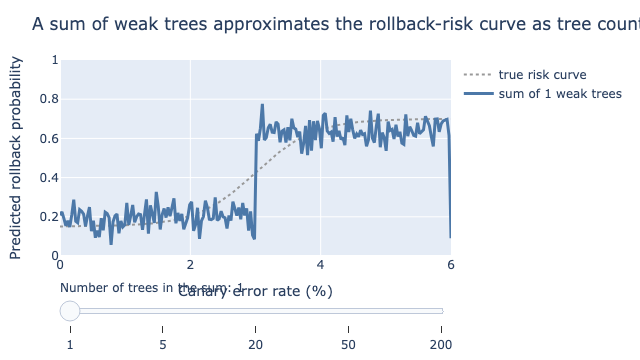

In [11]:
fig = FIGURES["chapter-bayes-bart-fig-ensemble-buildup"]()
fig

**`chapter-bayes-bart-fig-bart-vs-rf-interval`**

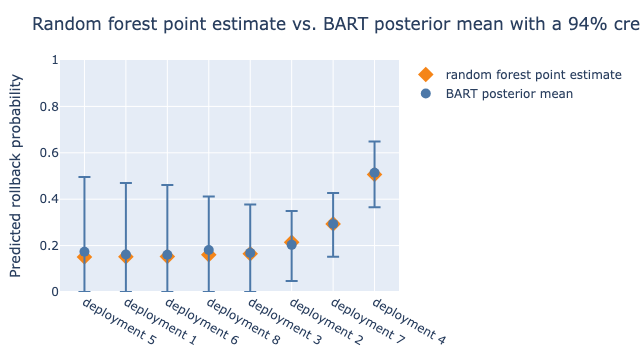

In [12]:
fig = FIGURES["chapter-bayes-bart-fig-bart-vs-rf-interval"]()
fig

**`chapter-bayes-bart-fig-variable-importance`**

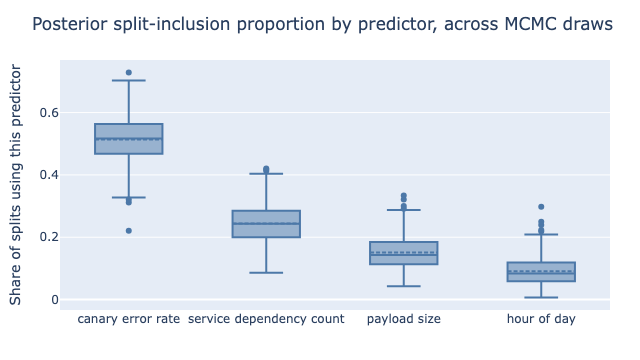

In [13]:
fig = FIGURES["chapter-bayes-bart-fig-variable-importance"]()
fig

**`chapter-bayes-bart-fig-mcmc-trace`**

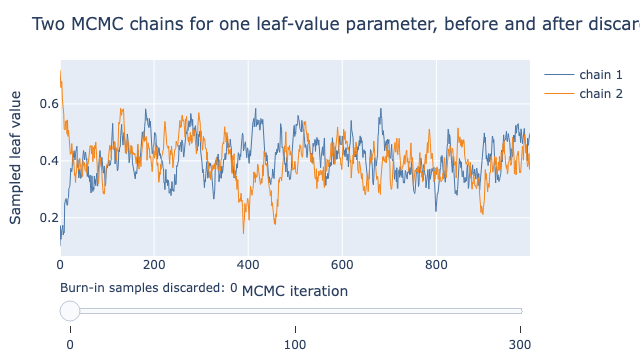

In [14]:
fig = FIGURES["chapter-bayes-bart-fig-mcmc-trace"]()
fig

**`chapter-bayes-bart-fig-tree-structure-prior`**

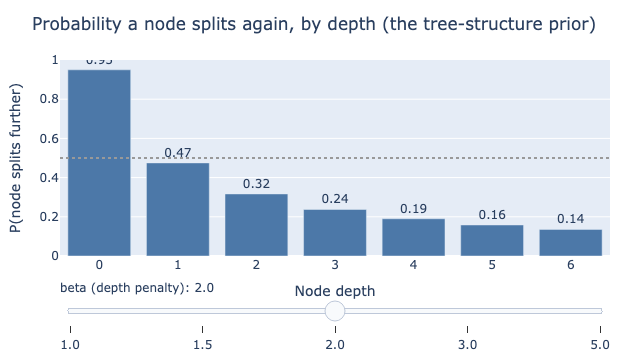

In [15]:
fig = FIGURES["chapter-bayes-bart-fig-tree-structure-prior"]()
fig